In [6]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import numpy as np
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [13]:
# Nettoyage de la base RMQS

# Chargment du dataset

sol = pd.read_csv("RMQS1_analyses_composites_18_11_2021_virgule.csv")

# Sélection des colonnes utiles ( pour l'agronomie)
colonnes = [
    "no_campagne","id_site","code_dept","date_complete",
    "x_theo","y_theo",
    "profondeur_hz_sup","profondeur_hz_inf",
    "argile","limon_fin","limon_grossier","sable_fin","sable_grossier",
    "cec_40_1","ph_eau_6_1",
    "carbone_16_5_1","mat_org_0","n_tot_31_1",
    "p_ass_81_1",
    "ca_ech_40_3","mg_ech_40_3","k_ech_40_3",
    "calc_tot_2_1_2",
    "cond_elec_119_1",
    "teneur_eau_res_166_1"
]

sol = sol[colonnes]

# Nettoyage des codes départements
sol["code_dept"] = sol["code_dept"].astype(str)
sol["code_dept"] = sol["code_dept"].str.strip()   
sol["code_dept"] = sol["code_dept"].str.replace(".0","", regex=False)
sol["code_dept"] = sol["code_dept"].str.zfill(2)

# Nettoyage des colonnes numériques
cols_num = sol.columns.difference(["code_dept","date_complete"])

for col in cols_num:
    sol[col] = (
        sol[col]
        .astype(str)
        .str.strip()
        .str.replace(",", ".")
    )
    sol[col] = pd.to_numeric(sol[col], errors="coerce")

# Convertir la date
sol["date_complete"] = pd.to_datetime(sol["date_complete"], errors="coerce")

# Supprimer les lignes totalement vides
sol = sol.dropna(how="all")

# Supprimer les lignes sans coordonnées
sol = sol.dropna(subset=["x_theo","y_theo"])



# Reset index
sol = sol.reset_index(drop=True)

# Vérification
print("Dimensions dataset :", sol.shape)
print("\nTypes de variables :")
print(sol.dtypes)

print("\nDépartements présents :")
print(sorted(sol["code_dept"].unique()))

# Sauvegarde du dataset propre
sol.to_csv("RMQS_sol_nettoye.csv", index=False)

print("\nDataset nettoyé sauvegardé : RMQS_sol_nettoye.csv")

Dimensions dataset : (4148, 25)

Types de variables :
no_campagne                      int64
id_site                          int64
code_dept                       object
date_complete           datetime64[ns]
x_theo                         float64
y_theo                         float64
profondeur_hz_sup                int64
profondeur_hz_inf                int64
argile                         float64
limon_fin                      float64
limon_grossier                 float64
sable_fin                      float64
sable_grossier                 float64
cec_40_1                       float64
ph_eau_6_1                     float64
carbone_16_5_1                 float64
mat_org_0                      float64
n_tot_31_1                     float64
p_ass_81_1                     float64
ca_ech_40_3                    float64
mg_ech_40_3                    float64
k_ech_40_3                     float64
calc_tot_2_1_2                 float64
cond_elec_119_1                float64
teneur_eau

In [1]:
# Création du score agronomique 

# Chargement  du dataset
df = pd.read_csv('RMQS_sol_nettoye.csv', parse_dates=['date_complete'])

# Définition des fonctions de score pour chaque variable agronomique

# Score : 0 = mauvais, 1 = moyen, 2 = optimal

def score_argile(val):
    if val < 20: return 0
    elif val < 40: return 1
    else: return 2

def score_limon_fin(val):
    if val < 10: return 0
    elif val < 30: return 1
    else: return 2

def score_limon_grossier(val):
    if val < 10: return 0
    elif val < 30: return 1
    else: return 2

def score_sable_fin(val):
    if val < 10: return 0
    elif val < 30: return 1
    else: return 2

def score_sable_grossier(val):
    if val < 20: return 0
    elif val < 50: return 1
    else: return 2

def score_cec(val):
    if val < 5: return 0
    elif val < 15: return 1
    else: return 2

def score_ph(val):
    if val < 5.5: return 0
    elif val <= 7: return 2
    else: return 1

def score_carbone(val):
    if val < 1: return 0
    elif val < 3: return 1
    else: return 2

def score_mat_org(val):
    if val < 2: return 0
    elif val < 5: return 1
    else: return 2

def score_n(val):
    if val < 0.1: return 0
    elif val < 0.3: return 1
    else: return 2

def score_p(val):
    if val < 10: return 0
    elif val < 30: return 1
    else: return 2

def score_ca(val):
    if val < 5: return 0
    elif val < 15: return 1
    else: return 2

def score_mg(val):
    if val < 2: return 0
    elif val < 5: return 1
    else: return 2

def score_k(val):
    if val < 0.1: return 0
    elif val < 0.3: return 1
    else: return 2

def score_calc_tot(val):
    if val < 5: return 0
    elif val < 20: return 1
    else: return 2

def score_cond_elec(val):
    if val < 50: return 0
    elif val < 200: return 1
    else: return 2

def score_eau(val):
    if val < 10: return 0
    elif val < 30: return 1
    else: return 2

# Application des fonctions sur les colonnes pertinentes

df['score_argile'] = df['argile'].apply(score_argile)
df['score_limon_fin'] = df['limon_fin'].apply(score_limon_fin)
df['score_limon_grossier'] = df['limon_grossier'].apply(score_limon_grossier)
df['score_sable_fin'] = df['sable_fin'].apply(score_sable_fin)
df['score_sable_grossier'] = df['sable_grossier'].apply(score_sable_grossier)
df['score_cec'] = df['cec_40_1'].apply(score_cec)
df['score_ph'] = df['ph_eau_6_1'].apply(score_ph)
df['score_carbone'] = df['carbone_16_5_1'].apply(score_carbone)
df['score_mat_org'] = df['mat_org_0'].apply(score_mat_org)
df['score_n'] = df['n_tot_31_1'].apply(score_n)
df['score_p'] = df['p_ass_81_1'].apply(score_p)
df['score_ca'] = df['ca_ech_40_3'].apply(score_ca)
df['score_mg'] = df['mg_ech_40_3'].apply(score_mg)
df['score_k'] = df['k_ech_40_3'].apply(score_k)
df['score_calc_tot'] = df['calc_tot_2_1_2'].apply(score_calc_tot)
df['score_cond_elec'] = df['cond_elec_119_1'].apply(score_cond_elec)
df['score_eau'] = df['teneur_eau_res_166_1'].apply(score_eau)

# Poids agronomiques
poids = {
    # Très importants
    'score_ph': 3,
    'score_mat_org': 3,
    'score_carbone': 3,

    # Importants
    'score_cec': 2,
    'score_n': 2,
    'score_p': 2,
    'score_k': 2,

    # Moyennement importants
    'score_ca': 1,
    'score_mg': 1,
    'score_calc_tot': 1,
    'score_cond_elec': 1,
    'score_eau': 1,

    # Texture (poids faible individuellement)
    'score_argile': 1,
    'score_limon_fin': 1,
    'score_limon_grossier': 1,
    'score_sable_fin': 1,
    'score_sable_grossier': 1
}

# Calcul du score pondéré
somme_ponderee = sum(df[col] * poids[col] for col in poids)
somme_poids = sum(poids.values())

df['score_agronomique'] = (somme_ponderee / somme_poids) * 50

# Sauvegarde du dataset avec scores
df.to_csv('RMQS_sol_score_agronomique.csv', index=False)

print("✅ Calcul des scores terminé. Fichier sauvegardé : RMQS_sol_score_agronomique.csv")



✅ Calcul des scores terminé. Fichier sauvegardé : RMQS_sol_score_agronomique.csv


Nombre de points SCOT : 39
Model: spherical, R²=-0.062, RMSE=7.916
Model: exponential, R²=-0.036, RMSE=7.819
Model: gaussian, R²=0.071, RMSE=7.405
Model: linear, R²=-0.051, RMSE=7.875
✅ Meilleur modèle : gaussian avec R²=0.071
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 101.24898552650056
Full Sill: 119.69040172302506
Range: 158270.736997333
Nugget: 18.441416196524504 



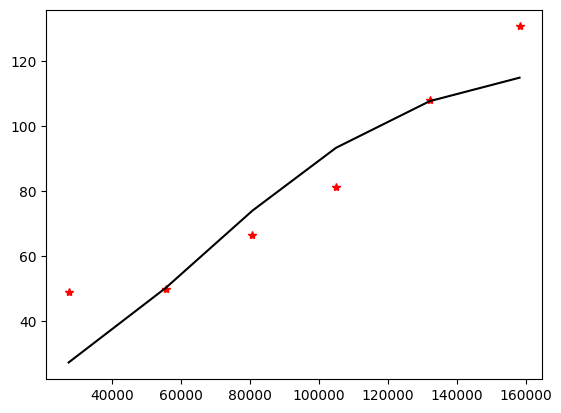

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



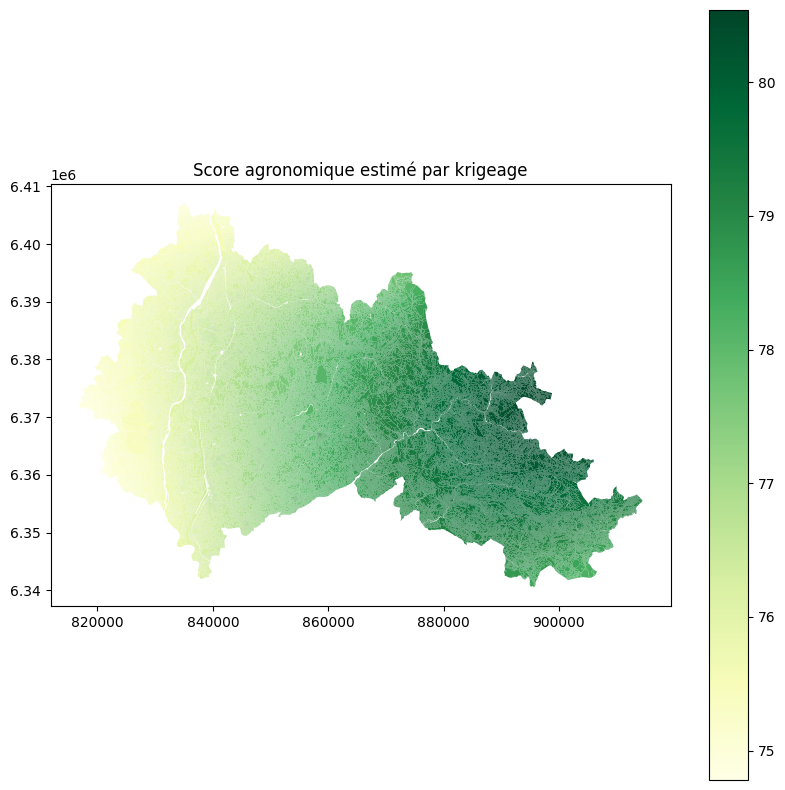

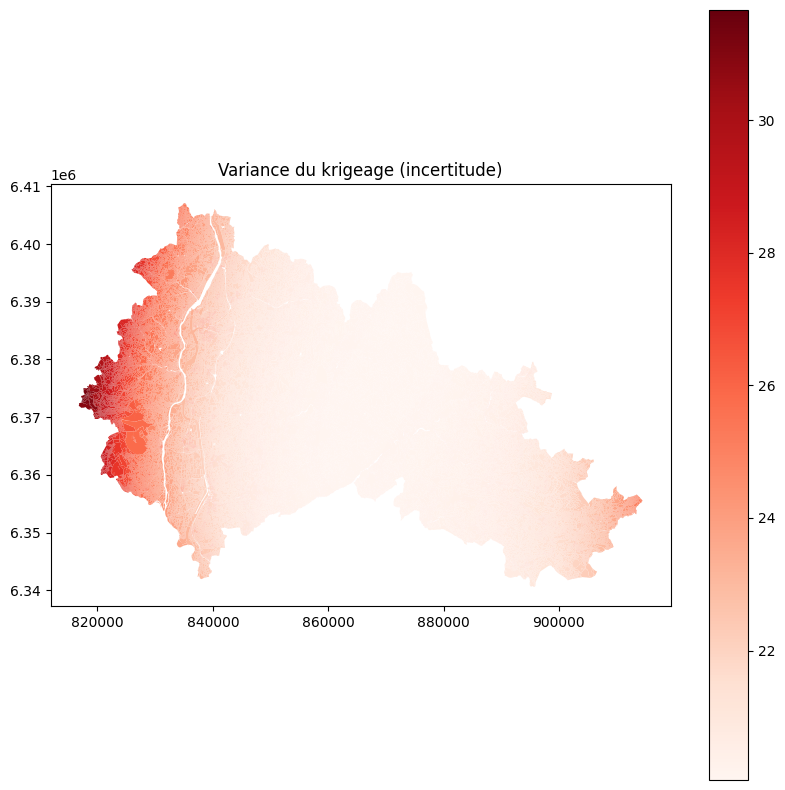

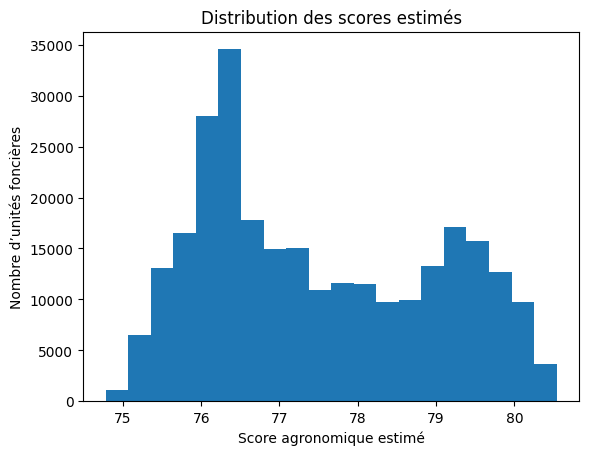

✅ GeoPackage sauvegardé avec scores estimés et variance.


In [9]:
# Kregeage departements 26 et 84 (Recherche du meilleur model)

# 1. Chargeement des données

df_scores = pd.read_csv('RMQS_sol_score_agronomique.csv')
gdf_uf = gpd.read_file('TUP_SCoT_RPB_CLEAN 1 2.gpkg', layer='tup_scot_rpb_clean')


# 2. Filtrer les départements SCOT

df_scores['code_dept'] = df_scores['code_dept'].astype(str)
df_scot = df_scores[df_scores['code_dept'].isin(['26', '84'])]
df_scot = df_scot.groupby(['x_theo','y_theo']).agg({'score_agronomique':'mean'}).reset_index()

x = df_scot['x_theo'].values
y = df_scot['y_theo'].values
z = df_scot['score_agronomique'].values

print(f"Nombre de points SCOT : {len(df_scot)}")


# 3. Vérifier et reprojeter CRS

# Si UF est géographique, reprojeter en Lambert-93
if gdf_uf.crs.is_geographic:
    gdf_uf = gdf_uf.to_crs("EPSG:2154")

# Si tes x/y sont en degrés, les convertir en Lambert-93
# Ici on suppose qu'ils sont en mètres ; sinon il faudrait reprojeter avec pyproj

# Centroids
gdf_uf['centroid'] = gdf_uf.geometry.centroid
gdf_uf['x'] = gdf_uf.centroid.x
gdf_uf['y'] = gdf_uf.centroid.y


# 4. Cross-validation + test modèles variogramme

variogram_models = ['spherical','exponential','gaussian','linear']
best_r2 = -np.inf
best_model = None

for model in variogram_models:
    observed = []
    predicted = []
    
    for i in range(len(x)):
        x_train = np.delete(x, i)
        y_train = np.delete(y, i)
        z_train = np.delete(z, i)
        
        OK_cv = OrdinaryKriging(
            x_train, y_train, z_train,
            variogram_model=model,
            verbose=False,
            enable_plotting=False
        )
        z_pred_i, ss_i = OK_cv.execute('points', np.array([x[i]]), np.array([y[i]]))
        observed.append(z[i])
        predicted.append(z_pred_i[0])
    
    r2 = r2_score(observed, predicted)
    rmse = np.sqrt(mean_squared_error(observed, predicted))
    print(f"Model: {model}, R²={r2:.3f}, RMSE={rmse:.3f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = model

print(f"✅ Meilleur modèle : {best_model} avec R²={best_r2:.3f}")


# 5. Krigeage avec le meilleur modèle

OK = OrdinaryKriging(
    x, y, z,
    variogram_model=best_model,
    verbose=True,
    enable_plotting=True
)

# Interpolation sur centroids des UF
z_pred, ss_uf = OK.execute('points', gdf_uf['x'].values, gdf_uf['y'].values)
gdf_uf['score_agronomique_estime'] = z_pred
gdf_uf['variance_krigeage'] = ss_uf


# 6. Visualisation

fig, ax = plt.subplots(1,1, figsize=(10,10))
gdf_uf.plot(column='score_agronomique_estime', cmap='YlGn', legend=True, ax=ax)
ax.set_title('Score agronomique estimé par krigeage')
plt.show()

# Carte de variance (incertitude)
fig, ax = plt.subplots(1,1, figsize=(10,10))
gdf_uf.plot(column='variance_krigeage', cmap='Reds', legend=True, ax=ax)
ax.set_title('Variance du krigeage (incertitude)')
plt.show()

# Histogramme des valeurs estimées
plt.hist(gdf_uf['score_agronomique_estime'], bins=20)
plt.xlabel('Score agronomique estimé')
plt.ylabel('Nombre d’unités foncières')
plt.title('Distribution des scores estimés')
plt.show()


# 7. Nettoyage et sauvegarde

gdf_uf = gdf_uf.drop(columns=['centroid'])
gdf_uf.to_file('unites_foncieres_score_estime.gpkg', layer='UF_score_estime', driver='GPKG')
print("✅ GeoPackage sauvegardé avec scores estimés et variance.")

Nombre de points pour krigeage après élargissement : 206
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 18.622966554128375
Full Sill: 66.5266402898629
Range: 230032.43727153286
Nugget: 47.90367373573452 



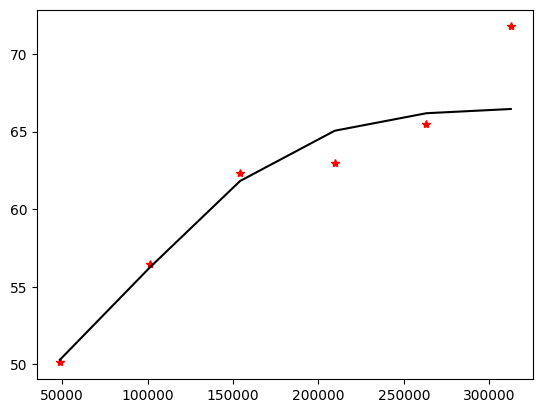

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



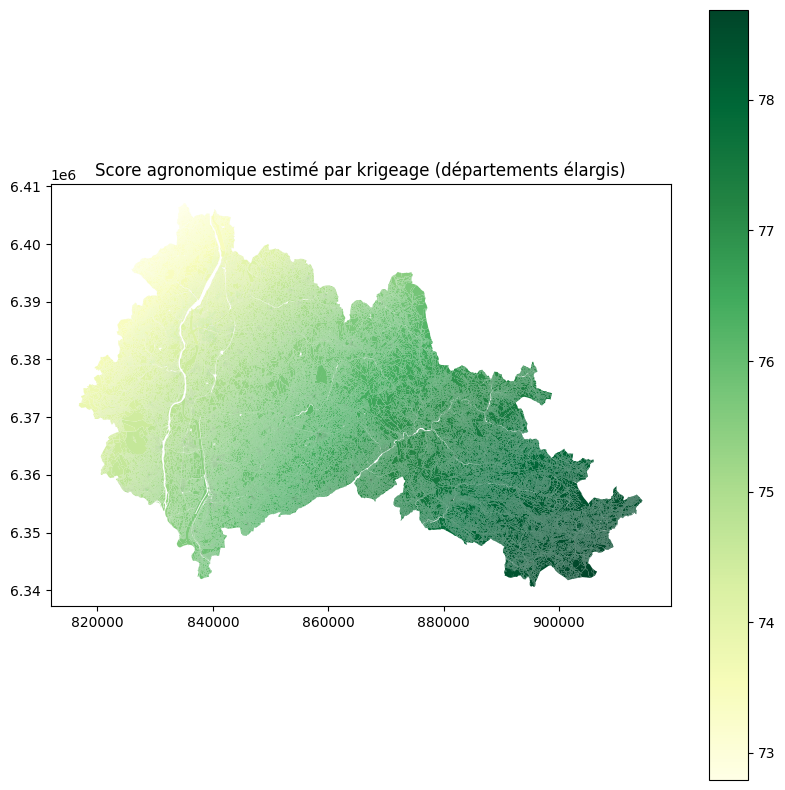

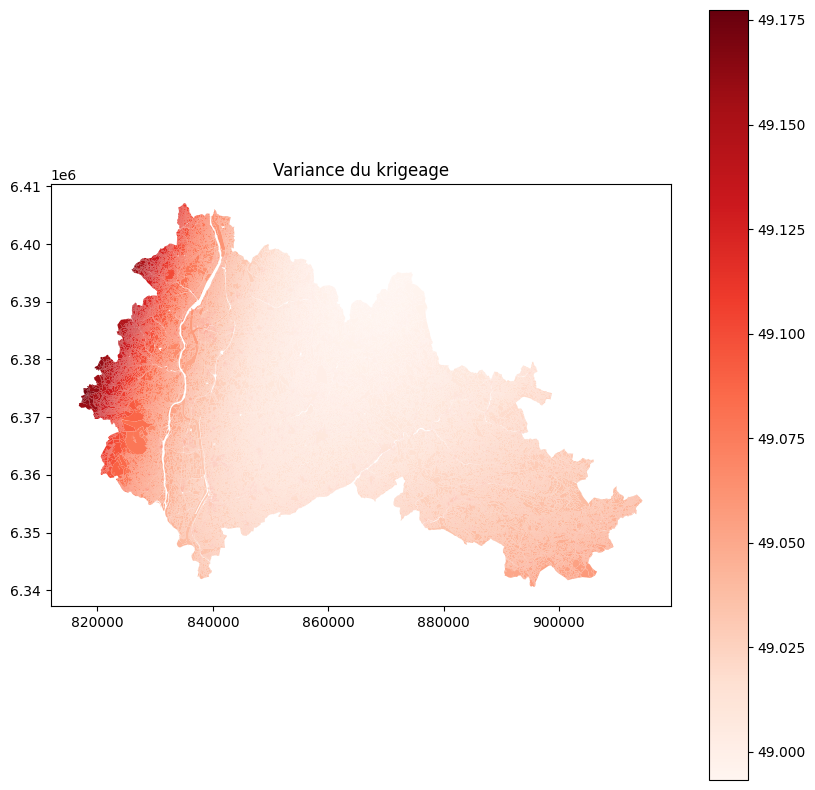

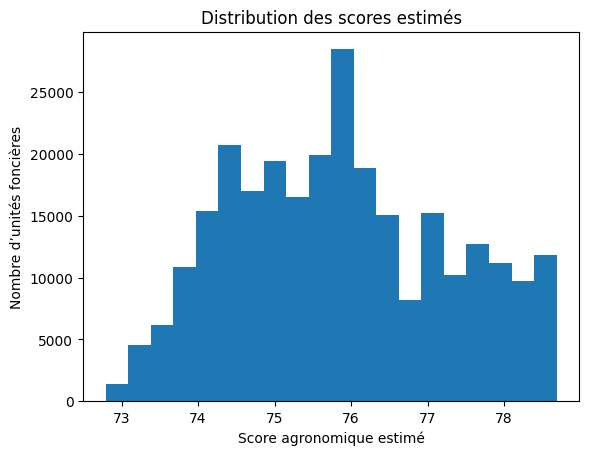

✅ GeoPackage sauvegardé avec scores estimés et variance.


In [10]:
# Script Kregeage pour les departements 04,05,07,13,26,30,38,42,69,84

# 1. Chargement des données

df_scores = pd.read_csv('RMQS_sol_score_agronomique.csv')  # RMQS points
gdf_uf = gpd.read_file('TUP_SCoT_RPB_CLEAN 1 2.gpkg', layer='tup_scot_rpb_clean')


# 2. Départements élargis autour de 26 et 84

dept_inclusion = ['04','05','07','13','26','30','38','42','69','84']
df_scores['code_dept'] = df_scores['code_dept'].astype(str)
df_scores_subset = df_scores[df_scores['code_dept'].isin(dept_inclusion)]

# Moyenne si doublons aux mêmes coordonnées
df_scores_subset = df_scores_subset.groupby(['x_theo','y_theo']).agg({'score_agronomique':'mean'}).reset_index()

x = df_scores_subset['x_theo'].values
y = df_scores_subset['y_theo'].values
z = df_scores_subset['score_agronomique'].values
print(f"Nombre de points pour krigeage après élargissement : {len(df_scores_subset)}")


# 3. Vérifier et reprojeter CRS

if gdf_uf.crs.is_geographic:
    gdf_uf = gdf_uf.to_crs("EPSG:2154")  # Lambert-93

# Centroids des UF SCOT
gdf_uf['centroid'] = gdf_uf.geometry.centroid
gdf_uf['x'] = gdf_uf.centroid.x
gdf_uf['y'] = gdf_uf.centroid.y


# 4. Krigeage rapide (gaussian)

OK = OrdinaryKriging(
    x, y, z,
    variogram_model='gaussian',
    verbose=True,
    enable_plotting=True
)

# Interpolation sur centroids UF SCOT
z_pred, ss_uf = OK.execute('points', gdf_uf['x'].values, gdf_uf['y'].values)
gdf_uf['score_agronomique_estime'] = z_pred
gdf_uf['variance_krigeage'] = ss_uf


# 5. Visualisation

# Carte des scores estimés
fig, ax = plt.subplots(1,1, figsize=(10,10))
gdf_uf.plot(column='score_agronomique_estime', cmap='YlGn', legend=True, ax=ax)
ax.set_title('Score agronomique estimé par krigeage (départements élargis)')
plt.show()

# Carte de variance (incertitude)
fig, ax = plt.subplots(1,1, figsize=(10,10))
gdf_uf.plot(column='variance_krigeage', cmap='Reds', legend=True, ax=ax)
ax.set_title('Variance du krigeage')
plt.show()

# Histogramme des valeurs estimées
plt.hist(gdf_uf['score_agronomique_estime'], bins=20)
plt.xlabel('Score agronomique estimé')
plt.ylabel('Nombre d’unités foncières')
plt.title('Distribution des scores estimés')
plt.show()


# 6. Sauvegarde

gdf_uf = gdf_uf.drop(columns=['centroid'])
gdf_uf.to_file('unites_foncieres_score_estime.gpkg', layer='UF_score_estime', driver='GPKG')
print("✅ GeoPackage sauvegardé avec scores estimés et variance.")

In [13]:
# Validaion croisée

preds = []
for i in range(len(x)):
    # Points sans le i-ème
    x_train = np.delete(x, i)
    y_train = np.delete(y, i)
    z_train = np.delete(z, i)
    
    OK_cv = OrdinaryKriging(
        x_train, y_train, z_train,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False
    )
    
    z_i, _ = OK_cv.execute('points', np.array([x[i]]), np.array([y[i]]))
    preds.append(z_i[0])

preds = np.array(preds)

# Calcul des erreurs
ME = np.mean(preds - z)  # erreur moyenne
RMSE = np.sqrt(mean_squared_error(z, preds))  # racine de l'erreur quadratique moyenne
MAE = mean_absolute_error(z, preds)

print(f"Validation croisée :\nErreur moyenne (ME) = {ME:.3f}\nRMSE = {RMSE:.3f}\nMAE = {MAE:.3f}")

Validation croisée :
Erreur moyenne (ME) = -0.013
RMSE = 7.084
MAE = 5.738


RMSE: 7.08
R²: 0.13


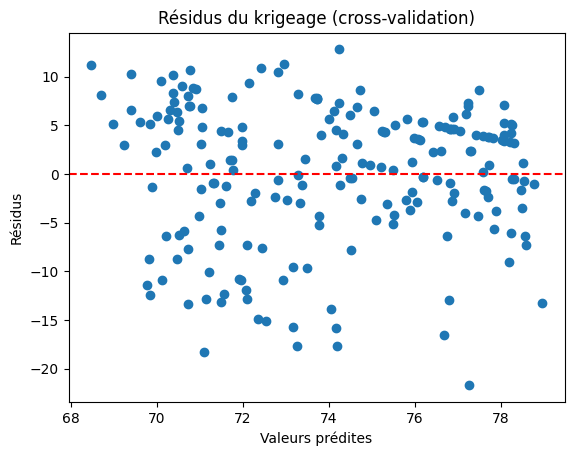

In [14]:
# visualisation des Residus

observed = []
predicted = []

for i in range(len(x)):
    x_train = np.delete(x, i)
    y_train = np.delete(y, i)
    z_train = np.delete(z, i)
    
    OK_cv = OrdinaryKriging(
        x_train, y_train, z_train,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False
    )
    
    z_pred_i, ss_i = OK_cv.execute('points', np.array([x[i]]), np.array([y[i]]))
    observed.append(z[i])
    predicted.append(z_pred_i[0])

observed = np.array(observed)
predicted = np.array(predicted)

rmse = np.sqrt(mean_squared_error(observed, predicted))
r2 = r2_score(observed, predicted)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")
residuals = observed - predicted
plt.scatter(predicted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus du krigeage (cross-validation)")
plt.show()

Nombre de points pour krigeage après élargissement : 514
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 15.459106081792502
Full Sill: 74.83574989714232
Range: 327015.3916050492
Nugget: 59.376643815349816 



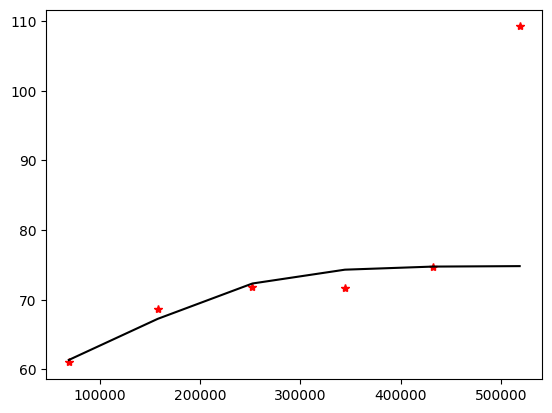

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



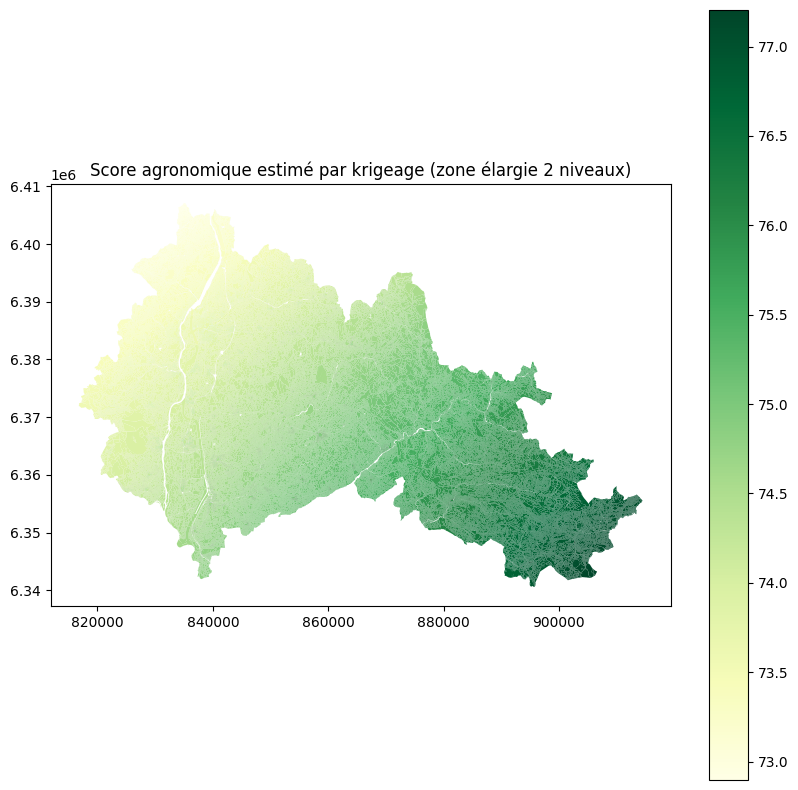

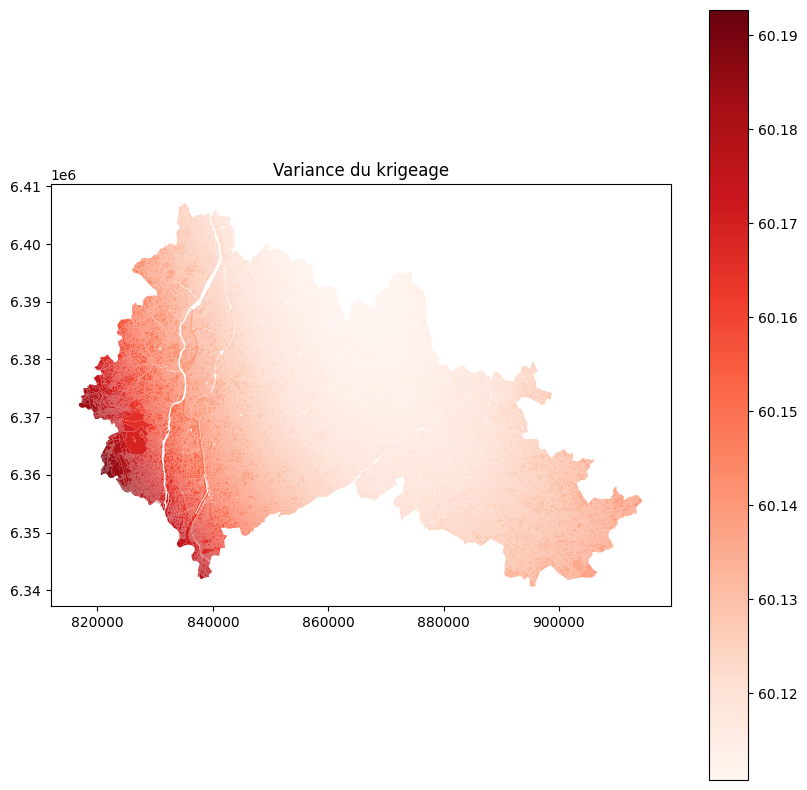

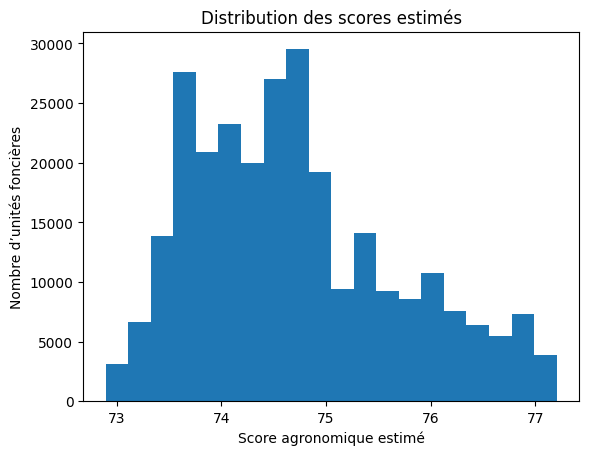

✅ GeoPackage sauvegardé avec scores estimés et variance.


In [15]:
#Script kregeage sur les departements 01,03,04,05,06,07,11,12,13,15,26,30,38,42,43,63,66,69,81,83,84,87

# 1. Chargement des données

df_scores = pd.read_csv('RMQS_sol_score_agronomique.csv')  # RMQS points
gdf_uf = gpd.read_file('TUP_SCoT_RPB_CLEAN 1 2.gpkg', layer='tup_scot_rpb_clean')


# 2. Départements élargis (2 niveaux autour de 26 et 84)

# Niveau 1 déjà inclus : 04,05,07,13,26,30,38,42,69,84
# Niveau 2 (limitrophes des voisins) : 01,03,06,11,12,15,43,63,66,81,83,87
dept_inclusion = [
    '01','03','04','05','06','07','11','12','13','15','26','30','31','38','42','43','63','66','69','81','83','84','87'
]
df_scores['code_dept'] = df_scores['code_dept'].astype(str)
df_scores_subset = df_scores[df_scores['code_dept'].isin(dept_inclusion)]

# Moyenne si doublons aux mêmes coordonnées
df_scores_subset = df_scores_subset.groupby(['x_theo','y_theo']).agg({'score_agronomique':'mean'}).reset_index()

x = df_scores_subset['x_theo'].values
y = df_scores_subset['y_theo'].values
z = df_scores_subset['score_agronomique'].values
print(f"Nombre de points pour krigeage après élargissement : {len(df_scores_subset)}")


# 3. Vérifier et reprojeter CRS

if gdf_uf.crs.is_geographic:
    gdf_uf = gdf_uf.to_crs("EPSG:2154")  # Lambert-93

# Centroids des UF SCOT
gdf_uf['centroid'] = gdf_uf.geometry.centroid
gdf_uf['x'] = gdf_uf.centroid.x
gdf_uf['y'] = gdf_uf.centroid.y


# 4. Krigeage rapide (gaussian)

OK = OrdinaryKriging(
    x, y, z,
    variogram_model='gaussian',
    verbose=True,
    enable_plotting=True
)

# Interpolation sur centroids UF SCOT
z_pred, ss_uf = OK.execute('points', gdf_uf['x'].values, gdf_uf['y'].values)
gdf_uf['score_agronomique_estime'] = z_pred
gdf_uf['variance_krigeage'] = ss_uf


# 5. Visualisation

# Carte des scores estimés
fig, ax = plt.subplots(1,1, figsize=(10,10))
gdf_uf.plot(column='score_agronomique_estime', cmap='YlGn', legend=True, ax=ax)
ax.set_title('Score agronomique estimé par krigeage (zone élargie 2 niveaux)')
plt.show()

# Carte de variance (incertitude)
fig, ax = plt.subplots(1,1, figsize=(10,10))
gdf_uf.plot(column='variance_krigeage', cmap='Reds', legend=True, ax=ax)
ax.set_title('Variance du krigeage')
plt.show()

# Histogramme des valeurs estimées
plt.hist(gdf_uf['score_agronomique_estime'], bins=20)
plt.xlabel('Score agronomique estimé')
plt.ylabel('Nombre d’unités foncières')
plt.title('Distribution des scores estimés')
plt.show()


# 6. Sauvegarde

gdf_uf = gdf_uf.drop(columns=['centroid'])
gdf_uf.to_file('unites_foncieres_score_estime.500+ points.gpkg', layer='UF_score_estime', driver='GPKG')
print("✅ GeoPackage sauvegardé avec scores estimés et variance.")

In [16]:
# Validation croiséé 

preds = []
for i in range(len(x)):
    # Points sans le i-ème
    x_train = np.delete(x, i)
    y_train = np.delete(y, i)
    z_train = np.delete(z, i)
    
    OK_cv = OrdinaryKriging(
        x_train, y_train, z_train,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False
    )
    
    z_i, _ = OK_cv.execute('points', np.array([x[i]]), np.array([y[i]]))
    preds.append(z_i[0])

preds = np.array(preds)

# Calcul des erreurs
ME = np.mean(preds - z)  # erreur moyenne
RMSE = np.sqrt(mean_squared_error(z, preds))  # racine de l'erreur quadratique moyenne
MAE = mean_absolute_error(z, preds)

print(f"Validation croisée :\nErreur moyenne (ME) = {ME:.3f}\nRMSE = {RMSE:.3f}\nMAE = {MAE:.3f}")

Validation croisée :
Erreur moyenne (ME) = -0.000
RMSE = 7.662
MAE = 6.269


RMSE: 7.66
R²: 0.15


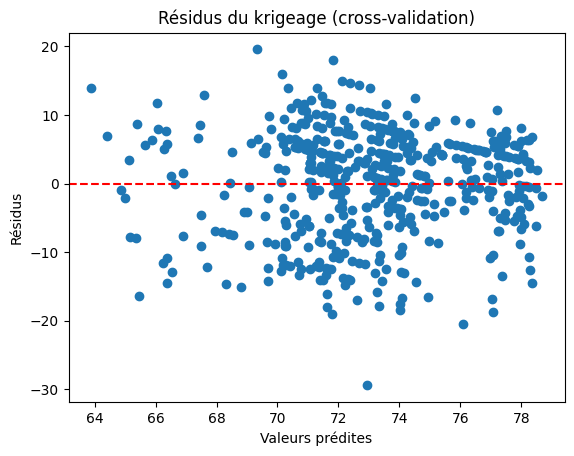

In [17]:
# Visualisation des residus
observed = []
predicted = []

for i in range(len(x)):
    x_train = np.delete(x, i)
    y_train = np.delete(y, i)
    z_train = np.delete(z, i)
    
    OK_cv = OrdinaryKriging(
        x_train, y_train, z_train,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False
    )
    
    z_pred_i, ss_i = OK_cv.execute('points', np.array([x[i]]), np.array([y[i]]))
    observed.append(z[i])
    predicted.append(z_pred_i[0])

observed = np.array(observed)
predicted = np.array(predicted)

rmse = np.sqrt(mean_squared_error(observed, predicted))
r2 = r2_score(observed, predicted)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")
residuals = observed - predicted
plt.scatter(predicted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus du krigeage (cross-validation)")
plt.show()